<a href="https://colab.research.google.com/github/Clint07-datascientist/ALU_Mission_Capstone/blob/main/Machine_Learning_Pipelin/Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fastapi uvicorn nest-asyncio pydantic

In [ ]:
# Importing all the necessary libraries
import os
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from fastapi import FastAPI
import nest_asyncio
import threading
from pydantic import BaseModel
import time
from google.colab import output
import uvicorn

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
# Paste your API token from the Kaggle popup here
os.environ["KAGGLE_API_TOKEN"] = "KGAT_2b013b5dcbafb2b8d60c189cfe8aa563"

print("Kaggle API Token configured!")

Kaggle API Token configured!


In [ ]:
# 2. Download the dataset
print("Downloading JMuBEN dataset...")
dataset_path = kagglehub.dataset_download("noamaanabdulazeem/jmuben-coffee-dataset")

print(f"Dataset downloaded successfully to: {dataset_path}")

# 3. Verify the contents to see the folder structure
print("\nFolders inside the dataset:")
print(os.listdir(dataset_path))

100%|██████████| 773M/773M [00:06<00:00, 126MB/s]

Extracting files...


Dataset downloaded successfully to: /root/.cache/kagglehub/datasets/noamaanabdulazeem/jmuben-coffee-dataset/versions/2

Folders inside the dataset:
['JMuBEN']


In [ ]:
# 1. Define your parameters
batch_size = 16
img_height = 224 # Required input size for MobileNetV3
img_width = 224

# 2. Only load the classes relevant to my Capstone scope
target_classes = ['Healthy', 'Leaf rust', 'Miner'] # Corrected capitalization for 'Leaf rust' again

# Adjust dataset_path to point to the correct subdirectory
import os
full_dataset_path = os.path.join(dataset_path, 'JMuBEN')

print("Loading Training Data...")
print(f"Target classes being used: {target_classes}") # Added print statement to verify target_classes
train_ds = tf.keras.utils.image_dataset_from_directory(
  full_dataset_path, # This is the corrected variable
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  class_names=target_classes # This automatically filters out Phoma and Cerscospora!
)

print("\nLoading Validation Data...")
print(f"Target classes being used: {target_classes}") # Added print statement to verify target_classes
val_ds = tf.keras.utils.image_dataset_from_directory(
  full_dataset_path,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  class_names=target_classes
)

# 3. Optimize for performance (Safely streaming from disk to prevent RAM crash)
AUTOTUNE = tf.data.AUTOTUNE

# .cache() has been removed!
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("\nData Pipeline Ready (RAM Safe)!")

Loading Training Data...
Target classes being used: ['Healthy', 'Leaf rust', 'Miner']
Found 44297 files belonging to 3 classes.
Using 35438 files for training.

Loading Validation Data...
Target classes being used: ['Healthy', 'Leaf rust', 'Miner']
Found 44297 files belonging to 3 classes.
Using 8859 files for validation.

Data Pipeline Ready (RAM Safe)!


Generating Image Sample Grid...


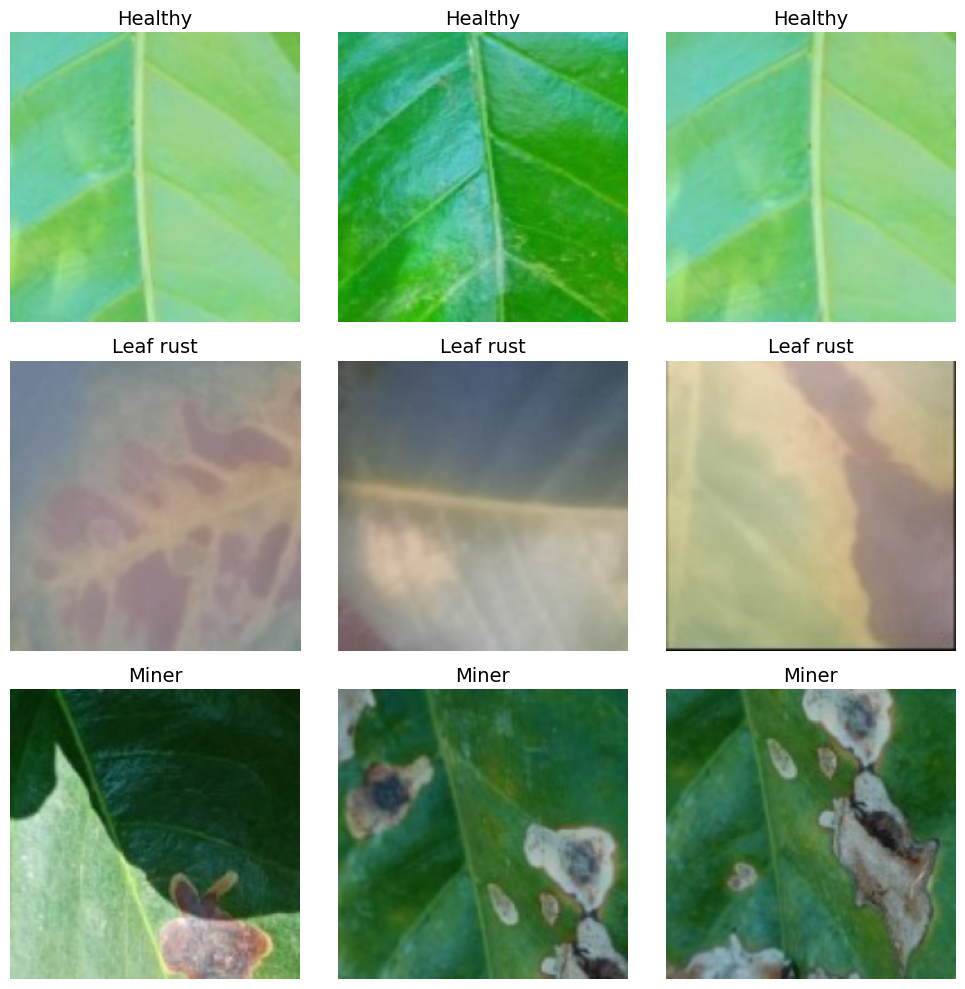

In [ ]:
# ---------------------------------------------------------
# VISUALIZATION 1: 3x3 Sample Image Grid
# ---------------------------------------------------------
print("Generating Image Sample Grid...")
plt.figure(figsize=(10, 10))
# Fix: Use target_classes directly as train_ds loses class_names after caching/prefetching
class_names = target_classes

# Track how many images of each class we've plotted
plotted_counts = {name: 0 for name in class_names}

# Scan through the dataset to find exactly 3 of each class
for images, labels in train_ds.unbatch().take(500):
    class_name = class_names[labels.numpy()]

    if plotted_counts[class_name] < 3:
        # Calculate grid position: Row = class index, Col = current count
        row = class_names.index(class_name)
        col = plotted_counts[class_name]
        position = (row * 3) + col + 1

        ax = plt.subplot(3, 3, position)
        plt.imshow(images.numpy().astype("uint8"))
        plt.title(f"{class_name}", fontsize=14)
        plt.axis("off")

        plotted_counts[class_name] += 1

    # Stop searching once we have 3 of each
    if all(count == 3 for count in plotted_counts.values()):
        break

plt.tight_layout()
plt.show()


Generating Class Distribution Chart...


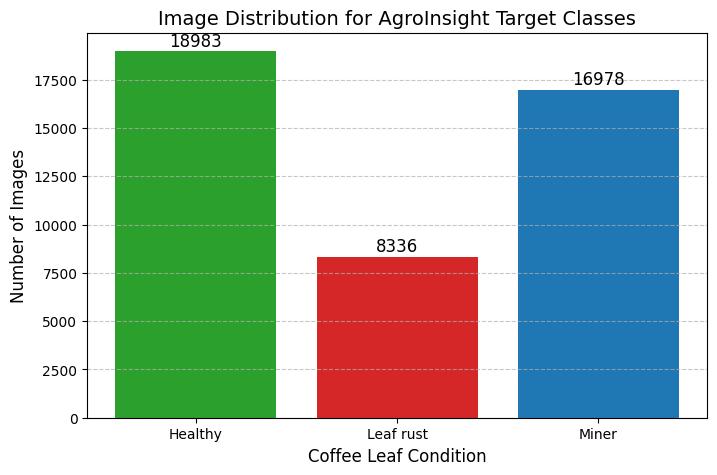

In [ ]:
# ---------------------------------------------------------
# VISUALIZATION 2: Class Distribution Bar Chart
# ---------------------------------------------------------
print("\nGenerating Class Distribution Chart...")

class_counts = []
for class_name in target_classes:
    # Correct the path: dataset_path points to the root,
    # but images are in JMuBEN/class_name
    folder_path = os.path.join(full_dataset_path, class_name)
    count = len(os.listdir(folder_path))
    class_counts.append(count)

plt.figure(figsize=(8, 5))
bars = plt.bar(target_classes, class_counts, color=['#2ca02c', '#d62728', '#1f77b4'])

# Add the exact numbers on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 50, int(yval), va='bottom', ha='center', fontsize=12)

plt.title('Image Distribution for AgroInsight Target Classes', fontsize=14)
plt.xlabel('Coffee Leaf Condition', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ---------------------------------------------------------
# MODEL ARCHITECTURE: MobileNetV3 (Small)
# ---------------------------------------------------------
print("Building MobileNetV3 Transfer Learning Model...")

# 1. Load the pre-trained base model (without the top classification layer)
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the base model to prevent destroying pre-trained weights during initial training
base_model.trainable = False

# 3. Add the custom classification head for AgroInsight
model = tf.keras.Sequential([
    # Add data augmentation to prevent overfitting
    tf.keras.layers.RandomFlip('horizontal_and_vertical', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.RandomRotation(0.2),

    # Base Model
    base_model,

    # Flatten the features using Global Average Pooling (more efficient than standard Flatten)
    tf.keras.layers.GlobalAveragePooling2D(),

    # Dense hidden layer with Dropout
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Drops 20% of neurons to prevent memorization

    # Output layer (3 neurons for Healthy, Leaf rust, Miner)
    tf.keras.layers.Dense(3, activation='softmax')
])

# 4. Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the architecture
model.summary()

Building MobileNetV3 Transfer Learning Model...
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,363 (3.87 MB)

 Trainable params: 74,243 (290.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

Training Model for up to 20 epochs...
Epoch 1/20
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 1.0000 - loss: 6.2540e-07 - val_accuracy: 1.0000 - val_loss: 3.8702e-06
Epoch 2/20
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 4.6629e-06
Epoch 3/20
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 1.0000 - loss: 2.6792e-07 - val_accuracy: 1.0000 - val_loss: 2.0144e-06
Epoch 4/20
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 1.0000 - loss: 3.1379e-07 - val_accuracy: 1.0000 - val_loss: 3.2913e-07
Epoch 5/20
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 1.0000 - loss: 4.0068e-04 - val_accuracy: 1.0000 - val_loss: 5.3825e-11
Epoch 6/20
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 1.0000 - loss: 2.1862e-05 - val_accuracy: 1.0000 - val_loss: 8.3429e-10
Epoch 7/20
2215/2215 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 1.0000 - loss: 3.0952e-08 - val_accuracy: 1.0000 - val_los

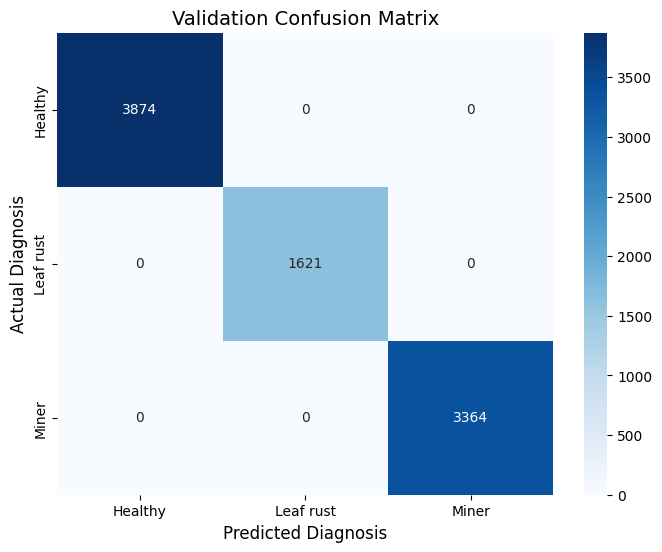

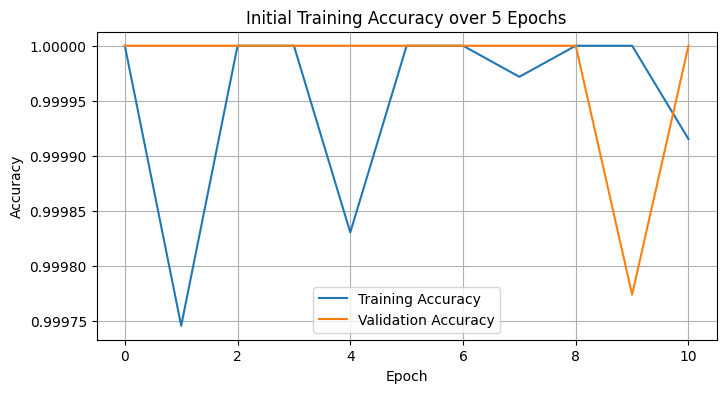

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# INITIAL PERFORMANCE METRICS WITH EARLY STOPPING
# ---------------------------------------------------------

# 1. Define the Early Stopping rule
early_stop = EarlyStopping(
    monitor='val_loss',        # Watch the validation loss for improvements
    patience=3,                # If it doesn't improve for 3 consecutive epochs, stop!
    restore_best_weights=True  # Automatically keep the best model, not the last model
)

# Safely set a high maximum epoch count
epochs = 20

print(f"Training Model for up to {epochs} epochs...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop]     # Inject the rule into the training loop
)

# Extract predictions for the validation set
print("\nGenerating Classification Report and Confusion Matrix...")
y_pred = []
y_true = []

# Iterate through validation data to get true labels and predict
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# 1. Print Accuracy, Precision, Recall, F1-Score
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_classes))

# 2. Plot Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes,
            yticklabels=target_classes)
plt.title('Validation Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.show()

# 3. Plot Training vs Validation Accuracy
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Initial Training Accuracy over 5 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ---------------------------------------------------------
# DEPLOYMENT OPTION: API Mockup (FastAPI / Swagger UI)
# ---------------------------------------------------------
# We use %%writefile to save this script as app.py.
# In a real deployment (e.g., on a cloud server or local testing),
# running `uvicorn app:app --reload` will automatically generate a Swagger UI at /docs

# 1. Define the expected JSON POST payload
class DiagnosticRequest(BaseModel):
    image_base64: str
    farm_location: str = "Rutsiro"
    hardware_id: str

# 2. Initialize the API with Capstone-specific documentation
app = FastAPI(
    title="AgroInsight Edge API (Mockup)",
    description="Interactive Swagger UI demonstrating the JSON POST endpoint for the MobileNetV3 coffee disease model.",
    version="1.0.0"
)

# 3. Create the POST endpoint
@app.post("/api/v1/diagnose", tags=["Inference"])
async def run_inference(payload: DiagnosticRequest):
    """
    Simulates receiving an image payload from the IoT probe and returning a diagnostic result.
    """
    # In a production environment, you would decode payload.image_base64 and run model.predict() here.
    # For this Capstone UI mockup, we return a simulated successful JSON response.

    return {
        "status": "success",
        "timestamp": time.time(),
        "device": payload.hardware_id,
        "location": payload.farm_location,
        "inference_results": {
            "disease_class": "Leaf rust",
            "confidence_score": 0.942,
            "model_version": "MobileNetV3_Quantized_v1"
        },
        "message": "Mock inference executed successfully."
    }

# 4. Background execution setup
def start_server():
    nest_asyncio.apply()
    # Run the server on localhost port 8000
    uvicorn.run(app, host="127.0.0.1", port=8000, log_level="error")

# Start the server in a parallel thread so the Colab cell doesn't freeze
api_thread = threading.Thread(target=start_server, daemon=True)
api_thread.start()

# Give the server a second to boot up
time.sleep(2)

# 5. Generate the public Colab URL to view the Swagger UI
print("✅ API Server is running in the background!")
print("Click the link below to open your interactive Swagger UI:")
output.serve_kernel_port_as_window(8000, path='/docs')

✅ API Server is running in the background!
Click the link below to open your interactive Swagger UI:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>